# Cardivascular Disease Prediction
The aim of this project is to create a model to predict the occurence of CDR in patients based on their medical records and medical history to calculate the probaility of the occurence of CDR in the patient. 

Dataset: https://www.kaggle.com/datasets/bertnardomariouskono/cardiovascular-disease-risk-prediction-dataset

In [158]:
# Import required lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Data Dictionary: Cardiovascular Disease Risk Prediction

| Feature Name | Data Type | Measurement Unit | Description | Expected Values / Range |
| :--- | :--- | :--- | :--- | :--- |
| **Patient_ID** | Integer | N/A | Unique identifier for each patient. | Unique ID |
| **Age** | Integer | Years | Age of the patient. | 25 – 85 |
| **Gender** | Binary | Categorical | Biological sex of the patient. | 0: Female, 1: Male |
| **Height_cm** | Float | cm | Patient's height in centimeters. | 120.0 – 220.0 |
| **Weight_kg** | Float | kg | Patient's weight in kilograms. | 40.0 – 200.0 |
| **BMI** | Float | kg/m² | Body Mass Index. | 15.0 – 50.0 |
| **Systolic_BP** | Integer | mmHg | Systolic Blood Pressure (at heart contraction). | 80 – 200 |
| **Diastolic_BP** | Integer | mmHg | Diastolic Blood Pressure (between beats). | 50 – 120 |
| **Cholesterol_Total**| Integer | mg/dL | Total serum cholesterol level. | 120 – 400 |
| **Cholesterol_LDL** | Integer | mg/dL | Low-Density Lipoprotein ("Bad" cholesterol). | 50 – 250 |
| **Cholesterol_HDL** | Integer | mg/dL | High-Density Lipoprotein ("Good" cholesterol). | 20 – 100 |
| **Fasting_BS** | Integer | mg/dL | Blood glucose level after fasting. | 70 – 250 |
| **Smoking_Status** | Binary | Categorical | Current smoking status. | 0: Non-smoker, 1: Smoker |
| **Alcohol_Cons.** | Integer | Categorical | Frequency of alcohol intake. | 0: None, 1: Moderate, 2: Heavy |
| **Physical_Activity**| Integer | Ordinal | Activity level scale. | 0: Sedentary to 3: High |
| **Family_History** | Binary | Categorical | Family history of heart disease. | 0: No, 1: Yes |
| **Stress_Level** | Integer | Ordinal | Self-reported stress level. | 1 (Low) – 10 (High) |
| **Sleep_Hours** | Integer | Hours | Average hours of sleep per night. | 3.0 – 12.0 |
| **Heart_Disease_Risk**| Binary | **Target** | Likelihood of cardiovascular disease. | 0: Low Risk, 1: High Risk |

In [138]:
# Load dataset
df = pd.read_csv('healthcare_synthetic_data.csv')
df.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               15000 non-null  object 
 1   Age                      15000 non-null  int64  
 2   Gender                   15000 non-null  int64  
 3   Height_cm                15000 non-null  float64
 4   Weight_kg                15000 non-null  float64
 5   BMI                      15000 non-null  float64
 6   Systolic_BP              15000 non-null  int64  
 7   Diastolic_BP             15000 non-null  int64  
 8   Cholesterol_Total        15000 non-null  int64  
 9   Cholesterol_LDL          15000 non-null  int64  
 10  Cholesterol_HDL          15000 non-null  int64  
 11  Fasting_Blood_Sugar      15000 non-null  int64  
 12  Smoking_Status           15000 non-null  int64  
 13  Alcohol_Consumption      15000 non-null  int64  
 14  Physical_Activity_Leve

## Data Preprocessing

In [140]:
# Check for null/values
df.isnull().sum()

Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL            0
Cholesterol_HDL            0
Fasting_Blood_Sugar        0
Smoking_Status             0
Alcohol_Consumption        0
Physical_Activity_Level    0
Family_History             0
Stress_Level               0
Sleep_Hours                0
Heart_Disease_Risk         0
dtype: int64

In [141]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,15000.0,54.538133,11.875294,25.0,46.0,55.0,63.0,85.0
Gender,15000.0,0.491867,0.499951,0.0,0.0,0.0,1.0,1.0
Height_cm,15000.0,165.336767,9.186313,138.5,158.5,164.7,172.0,198.1
Weight_kg,15000.0,75.252573,14.110559,33.7,65.2,73.9,83.9,150.1
BMI,15000.0,27.446080,4.134953,14.5,24.5,27.2,30.0,46.1
Systolic_BP,15000.0,135.117667,11.260634,90.0,127.0,135.0,143.0,182.0
Diastolic_BP,15000.0,90.541267,8.443095,60.0,85.0,91.0,96.0,120.0
Cholesterol_Total,15000.0,216.248000,22.692222,127.0,201.0,216.0,231.0,303.0
Cholesterol_LDL,15000.0,140.355267,17.914089,70.0,128.0,140.0,152.0,210.0
Cholesterol_HDL,15000.0,43.307867,5.963153,20.0,39.0,43.0,47.0,68.0


The target variable, Heart_Disease_Risk, has a mean of 0.436, indicating that 43.6% of the records represent high-risk cases. Because the classes are relatively well-balanced, there is no requirement for oversampling or undersampling. This distribution provides a sufficient signal-to-noise ratio for the model to effectively learn the underlying patterns of both risk categories.

## Exploratory Data Analysis (EDA)
The goal of this section is to investigate the underlying distributions of the clinical and lifestyle features. I will perform bivariate and multivariate analyses to identify key drivers of cardiovascular risk and uncover non-linear relationships between the features and the target variable.

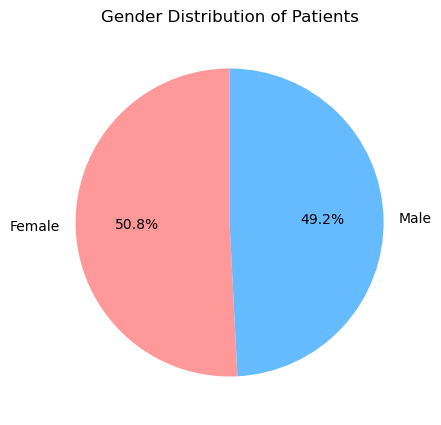

In [142]:
plt.figure(figsize=(5, 5))
gender_counts = df['Gender'].value_counts()
# 0 = Female, 1 = Male
labels = ['Female' if i == 0 else 'Male' for i in gender_counts.index]

plt.pie(gender_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66bbff'])
plt.title('Gender Distribution of Patients')
plt.show()

This pie chart shows the nearly even distribution between female and male patients within the dataset. This is significant as CDR can present differently across genders and having a balanced dataset ensures that the model that learns on this dataset is unbiased towards gender.

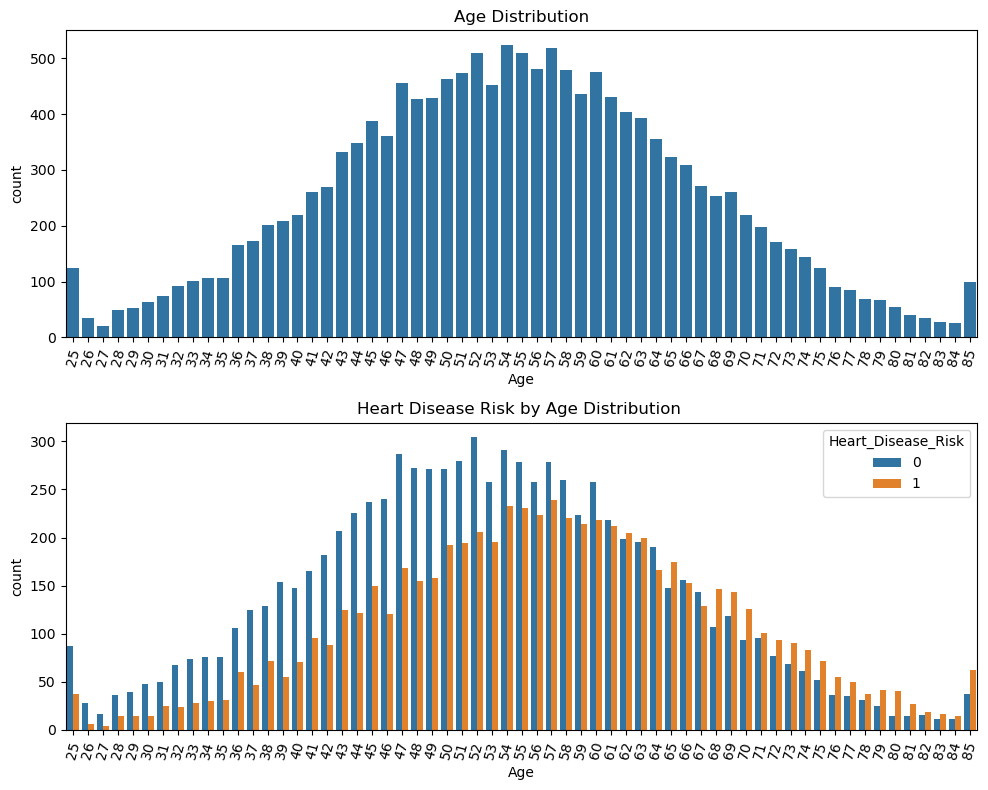

In [143]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
sns.countplot(x='Age', data=df, ax=ax[1], hue='Heart_Disease_Risk')
ax[1].set_title('Heart Disease Risk by Age Distribution ')
ax[1].tick_params(axis='x', rotation=75)

sns.countplot(x='Age', data=df, ax=ax[0])
ax[0].set_title('Age Distribution')
ax[0].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

The top chart shows the dataset follows a near normal distribtion, centered around the median age of ~54-55 years. This provides a statisically robust sample size for the middle-age bracket.

The bottom chart, which distinguishes between low risk and high risk patients, reveals a significant trend. In the younger cohorts, the majority of patients are categorised as low risk. However, as age increases, the gap narrows and it can be observed the crossover point starting around age 60, where the count of high risk patients begins to equal or exceed the low risk patients. This visual evidence suports the medical consensus that age is a primary independent risk factor for CDR.

The clear separation of risk counts as age progresses suggests that the Age will likely have high permutation importance in our final predictive model.

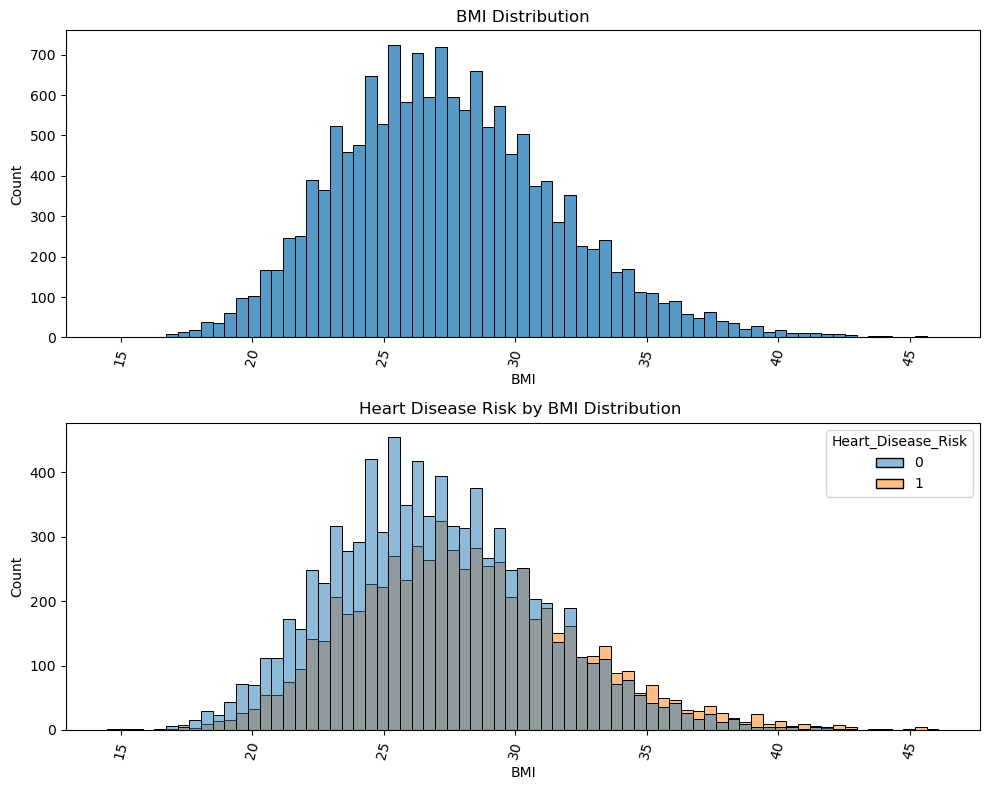

In [144]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
sns.histplot(x='BMI', data=df, ax=ax[1], hue='Heart_Disease_Risk')
ax[1].set_title('Heart Disease Risk by BMI Distribution ')
ax[1].tick_params(axis='x', rotation=75)

sns.histplot(x='BMI', data=df, ax=ax[0])
ax[0].set_title('BMI Distribution')
ax[0].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

The top historgram shows a right-skewed normal distribution. While the peak(mode) sits within the 25-28 range (Overweight), there is a significant "long tail" extending into the 35-45 range, representing patients with Class II and Class III obesity.

In the bottom historgram, we see a clear transition. In the "Healthy" BMI range (18-24), the low Risk (Blue) counts significantly outweight the HIgh Risk (Orange) counts. As BMI increases past 30, the porportions shift.
- As patients enter the obese category BMI>30, the high risk begin to dominate the distribution. When BMI reaches 35+ the majority of patients in those bins are classificed as high risk.

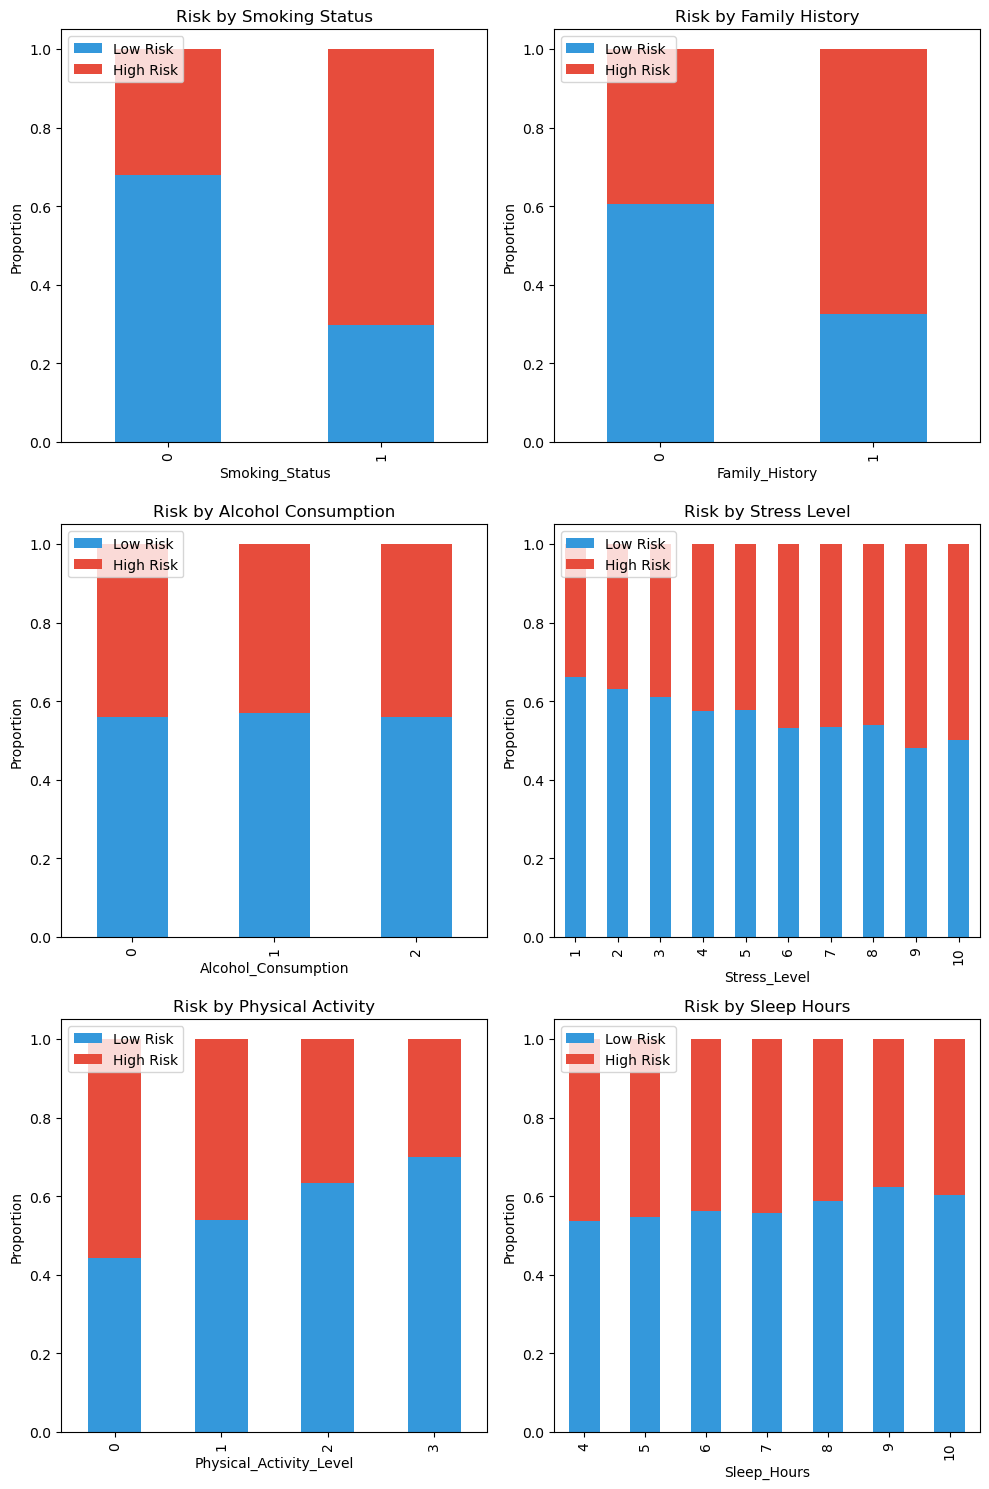

In [145]:
fig, ax = plt.subplots(3, 2, figsize=(10,15))
# Smoking Status vs Risk (Top Left)
pd.crosstab(df['Smoking_Status'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax[0, 0])
ax[0, 0].set_title('Risk by Smoking Status')
# Family History vs Risk (Top Right)
pd.crosstab(df['Family_History'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax[0, 1])
ax[0, 1].set_title('Risk by Family History')
# Alcohol Consumption vs Risk (Middle Left)
pd.crosstab(df['Alcohol_Consumption'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax[1, 0])
ax[1, 0].set_title('Risk by Alcohol Consumption')
# Stress Level vs Risk (Middle Right)
pd.crosstab(df['Stress_Level'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax[1, 1])
ax[1, 1].set_title('Risk by Stress Level')
# Physical Activity vs Risk (Bottom Left)
pd.crosstab(df['Physical_Activity_Level'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax[2, 0])
ax[2, 0].set_title('Risk by Physical Activity')
# Sleep Hours vs Risk (Bottom right)
pd.crosstab(df['Sleep_Hours'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=ax[2, 1])
ax[2, 1].set_title('Risk by Sleep Hours')

for a in ax.flat:
    a.set_ylabel('Proportion')
    a.legend(['Low Risk', 'High Risk'], loc='upper left')

plt.tight_layout()
plt.show()

This multivariate analysis shows how external and hereditary factors contrigute to CDR. By normalising the data, we can directly observe the *risk probability* across different patient segments.

- Smoking and Family History: These two features show the most dramatic impact. For both smokers and patients with a family history, the High Risk (Red) proportion increases significantly, roughly doubling compared to their counterparts.
- Alcohol Consumption: Interestingly, the risk proportion remains relatively stable across all levels (None, Moderate, Heavy) in this specific dataset. This suggests that while alcohol may impact health in other ways, it may not be a strong predictor for HDR.
- Stress Level:  There is a clear staircase effect. AS the self-reported stress levels increase from 1 to 10, there is a visible and steady expansion of the high-risk proportion.
- Physical Activity Level: There is a striking, near-linear relationship between activity levels and heart disease risk. Patients at Level 0 (Sedentary) have a significantly higher proportion of high risk. As physical activity increases to Level 3, the low risk.
- Sleep Hours: The data shows a weak trend. Patients getting very little sleep (4-5 hours) show a higher proportion of risk compared to these in the 8-9 hour range.

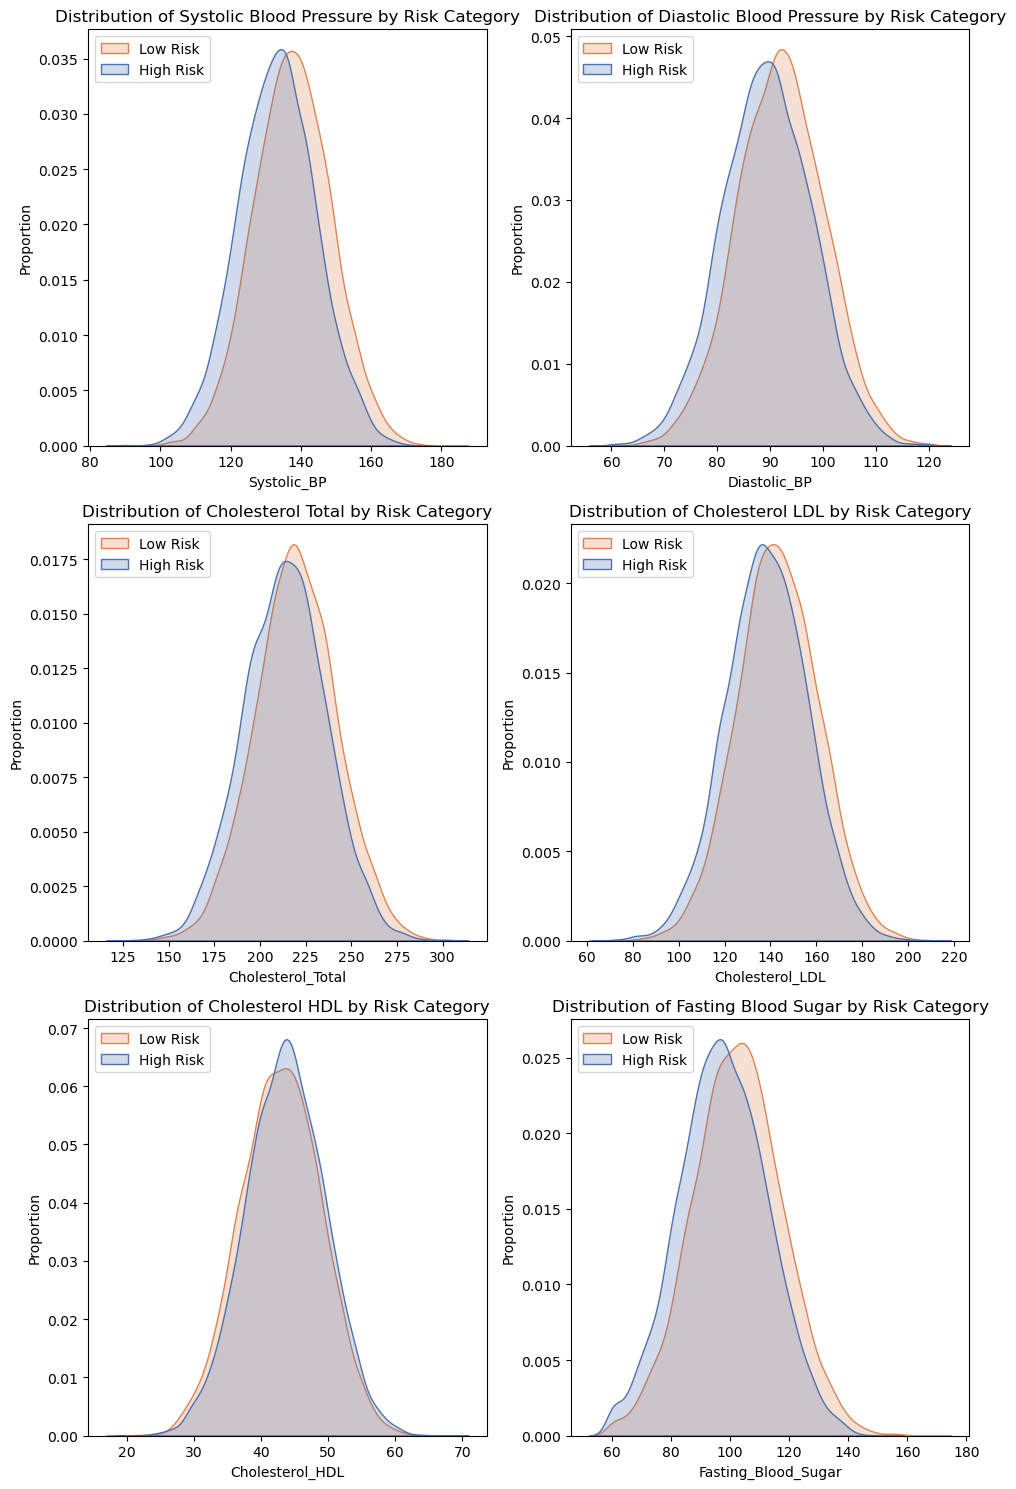

In [146]:
fig, ax = plt.subplots(3, 2, figsize=(10,15))
sns.kdeplot(data=df, x='Systolic_BP', hue='Heart_Disease_Risk', fill=True, palette='deep', common_norm=False, ax=ax[0, 0])
ax[0, 0].set_title('Distribution of Systolic Blood Pressure by Risk Category')

sns.kdeplot(data=df, x='Diastolic_BP', hue='Heart_Disease_Risk', fill=True, palette='deep', common_norm=False, ax=ax[0, 1])
ax[0, 1].set_title('Distribution of Diastolic Blood Pressure by Risk Category')

sns.kdeplot(data=df, x='Cholesterol_Total', hue='Heart_Disease_Risk', fill=True, palette='deep', common_norm=False, ax=ax[1, 0])
ax[1, 0].set_title('Distribution of Cholesterol Total by Risk Category')

sns.kdeplot(data=df, x='Cholesterol_LDL', hue='Heart_Disease_Risk', fill=True, palette='deep', common_norm=False, ax=ax[1, 1])
ax[1, 1].set_title('Distribution of Cholesterol LDL by Risk Category')

sns.kdeplot(data=df, x='Cholesterol_HDL', hue='Heart_Disease_Risk', fill=True, palette='deep', common_norm=False, ax=ax[2, 0])
ax[2, 0].set_title('Distribution of Cholesterol HDL by Risk Category')

sns.kdeplot(data=df, x='Fasting_Blood_Sugar', hue='Heart_Disease_Risk', fill=True, palette='deep', common_norm=False, ax=ax[2, 1])
ax[2, 1].set_title('Distribution of Fasting Blood Sugar by Risk Category')

for a in ax.flat:
    a.set_ylabel('Proportion')
    a.legend(['Low Risk', 'High Risk'], loc='upper left')

plt.tight_layout()
plt.show()

- Blood Pressure (Systolic & Diastolic): Both plots show a distinct "right-shift" for high-risk patients. While the low-risk group peaks around 125/80 mmHg, the high-risk group shows a significantly higher density between 140–160 mmHg (Systolic) and 90–100 mmHg (Diastolic). This clear separation indicates that hypertension is a primary driver in this dataset.

- Cholesterol Profile (Total & LDL): Total Cholesterol and LDL ("Bad" Cholesterol) mirror each other closely, with high-risk patients showing a broader, higher-reaching distribution. The crossover point for LDL appears around 140 mg/dL, after which the probability of being high-risk increases substantially.

- HDL Cholesterol ("Good" Cholesterol): In contrast to the other markers, the high-risk distribution for HDL is shifted to the left. This confirms the clinical expectation that lower levels of HDL are associated with higher cardiovascular risk, while higher levels (above 60 mg/dL) appear protective.

- Fasting Blood Sugar: This distribution shows the most significant overlap, though the high-risk group has a much "fancier" tail extending toward the 140+ mg/dL range. This suggests that while blood sugar is an important factor, it may work in tandem with other features (like BMI) rather than being a standalone indicator for everyone in the set.

In [147]:
# A simple binary feature
df['Is_Hypertensive'] = ((df['Systolic_BP'] >= 140) | (df['Diastolic_BP'] >= 90)).astype(int)

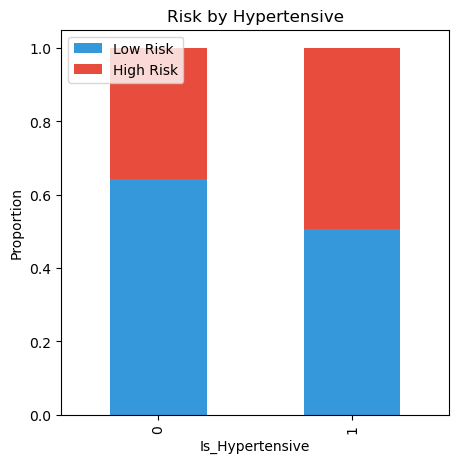

In [148]:
pd.crosstab(df['Is_Hypertensive'], df['Heart_Disease_Risk'], normalize='index').plot(
    kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(5, 5))
plt.title('Risk by Hypertensive')
plt.ylabel('Proportion')
plt.legend(['Low Risk', 'High Risk'], loc='upper left')
plt.show()

The risk by Hypertension chart demonstrates the significant correlation between clinical hypertensive thresholds (SBP>=140 or DBP>=90 mmHg) and cardiovascular disease risk. This engineered feature serves as a powerful binary indicator, showing a dramatic expansion in the high risk proportion compared to normotensive patients. This confirms that the combined elevation of blood pressure markers is a primary driver of the target variable.

## Data Processing

In [163]:
df_processed = df.copy()
# Drop Column Patient ID non-predictive columns
df_processed.drop(['Patient_ID'], axis=1, inplace=True, errors='ignore')

# One-Hot Encoding for Nominal Categorical Variables
df_processed = pd.get_dummies(df_processed, 
                              columns=['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption'], drop_first=True)
# Stress_Level and Physical_Activity as they are Ordinal Variables and have meaningful numeric scale

# Coorelation Matrix Heatmap

<Axes: >

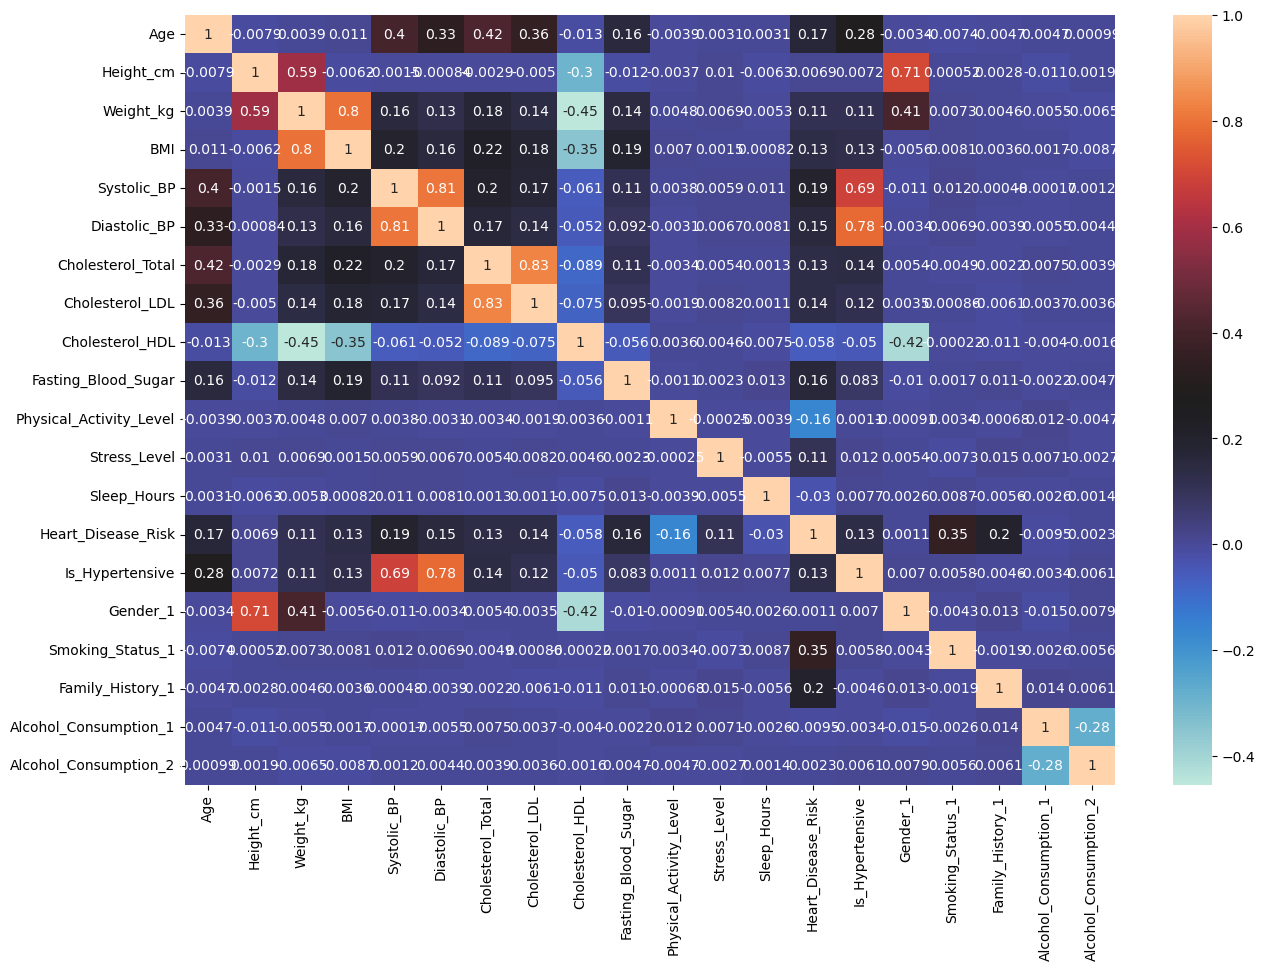

In [164]:
plt.figure(figsize=(15,10))
sns.heatmap(df_processed.corr(), annot = True, cmap = 'icefire')

In [166]:
# coorelation between the Heart_Disease_Risk and the other columns
df_processed.corr()['Heart_Disease_Risk'].sort_values()

Physical_Activity_Level   -0.162469
Cholesterol_HDL           -0.058043
Sleep_Hours               -0.030232
Alcohol_Consumption_1     -0.009458
Gender_1                   0.001127
Alcohol_Consumption_2      0.002324
Height_cm                  0.006888
Stress_Level               0.105946
Weight_kg                  0.110880
BMI                        0.132505
Cholesterol_Total          0.134230
Is_Hypertensive            0.134938
Cholesterol_LDL            0.135821
Diastolic_BP               0.154826
Fasting_Blood_Sugar        0.159159
Age                        0.168649
Systolic_BP                0.194210
Family_History_1           0.201332
Smoking_Status_1           0.352467
Heart_Disease_Risk         1.000000
Name: Heart_Disease_Risk, dtype: float64

### Multi-collinearity (Redundant Information)
- Systolic_BP vs. Diastolic_BP (0.81): Linked together
- Cholesterol_Total vs. Cholesterol_LDL (0.83): LDL is a major component of total cholesterol
- Weight_kg vs. BMI(0.80): BMI is derived from weight
- Is_Hypertensive vs. Diastolic_BP (0.78)
Since these high multi-collinearity can confuse certian models like Logistic Regression, it's best to remove one member of each pair to improve model interpretability.

Cholesterol_HDL ("Good" Cholesterol): Shows a negative correlation with BMI (-0.35) and Weight (-0.45).
Age vs. Cholesterol/BP: Age shows moderate positive correlations (0.33 to 0.42) with blood pressure and cholesterol. This shows that as age increases these are the leading causes of the increased risk of Heart Disease Risk.

### Top Predictors for Heart Disease Risk.
1. Smoking_Status (0.35)
2. Family_History (0.20)
3. Systolic_BP (0.19)
4. Age (0.17)
5. Physical_Activity_Level (-0.16)

# Train Test Split

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    df_processed.drop(columns = ['Heart_Disease_Risk']), df_processed['Heart_Disease_Risk'], 
    test_size = 0.2, random_state = 0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cardiovascular Disease Prediction

For predicting the cardiovascular disease, I will be using the following classification models:
- Random Forest Classifier
- Decision Tree Classifier
- Logistic Regression

To test the classification models I will be using:
- Confusion Matrix
- Accuracy Score
- Precision Score
- Recall Score
- F1 Score

# Random Forest Classifier

In [173]:
# Create Random Forest object
rfc = RandomForestClassifier(random_state=0, max_features='sqrt', n_estimators=200, class_weight='balanced')

In [174]:
# Training the model
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=0)

In [175]:
# Training accuracy
rfc.score(X_train, y_train)

1.0

# Decision Tree Classifier

In [227]:
# Create Decision Tree object
dtc = DecisionTreeClassifier(random_state=0, max_depth=10, min_samples_leaf=2, min_samples_split=2, class_weight='balanced')

In [228]:
# Training the model
dtc.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, random_state=0)

In [229]:
# Training accuracy
dtc.score(X_train, y_train)

0.8065

# Logistic Regression

In [212]:
# Create Logistic Regression object
lr = LogisticRegression(random_state=0, max_iter=5000)

In [220]:
#Training the model
lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=0)

In [221]:
#Training accuracy
lr.score(X_train, y_train)

0.7401666666666666

# Model Evalution

In [232]:
# Predicting the test set results
rfc_pred = rfc.predict(X_test)
dtc_pred = dtc.predict(X_test)
lr_pred = lr.predict(X_test)

Text(0.5, 1.0, 'Logistic Regression')

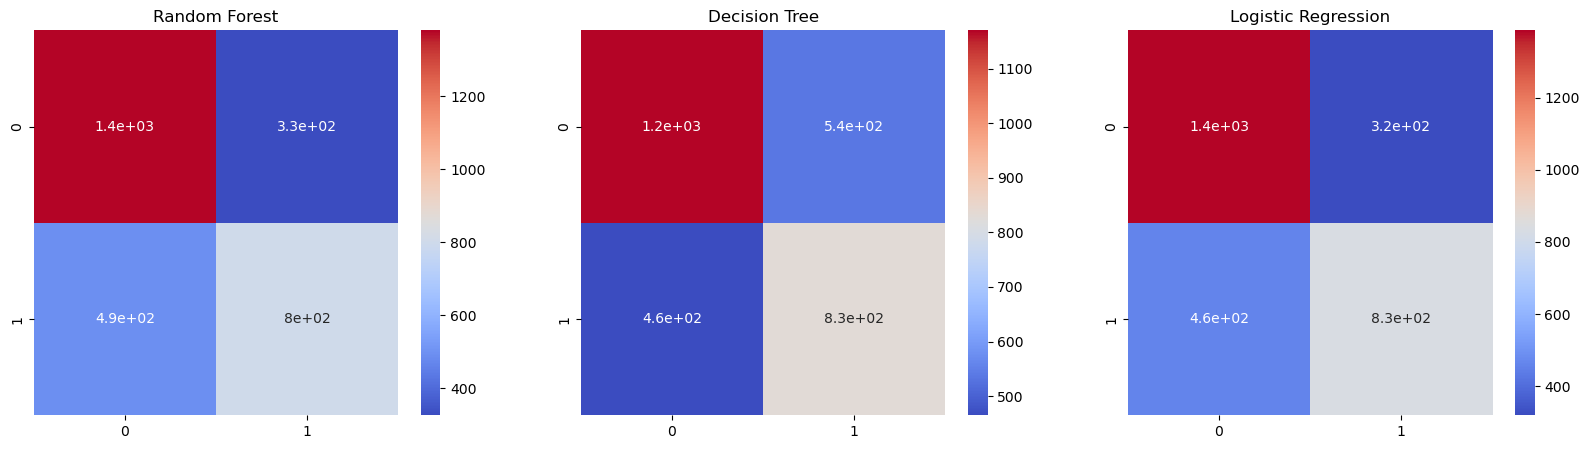

In [230]:
fig, ax  = plt.subplots(1,3, figsize = (20,5))
sns.heatmap(confusion_matrix(y_test, rfc_pred), annot=True, cmap='coolwarm', ax=ax[0]).set_title('Random Forest')
sns.heatmap(confusion_matrix(y_test, dtc_pred), annot=True, cmap='coolwarm', ax=ax[1]).set_title('Decision Tree')
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, cmap ='coolwarm', ax=ax[2]).set_title('Logistic Regression')

In [224]:
print('Random Forest')
print('Accuracy Score: ', accuracy_score(y_test, rfc_pred))
print('Precision Score: ', precision_score(y_test, rfc_pred))
print('Recall Score: ', recall_score(y_test, rfc_pred))
print('F1 Score: ', f1_score(y_test, rfc_pred))

Random Forest
Accuracy Score:  0.727
Precision Score:  0.7107364685004437
Recall Score:  0.6190108191653787
F1 Score:  0.6617100371747212


In [234]:
print('Decision Tree')
print('Accuracy Score: ', accuracy_score(y_test, dtc_pred))
print('Precision Score: ', precision_score(y_test, dtc_pred))
print('Recall Score: ', recall_score(y_test, dtc_pred))
print('F1 Score: ', f1_score(y_test, dtc_pred))

Decision Tree
Accuracy Score:  0.6826666666666666
Precision Score:  0.6315384615384615
Recall Score:  0.634466769706337
F1 Score:  0.6329992289899768


In [226]:
print('Logistic Regression')
print('Accuracy Score: ', accuracy_score(y_test, lr_pred))
print('Precision Score: ', precision_score(y_test, lr_pred))
print('Recall Score: ', recall_score(y_test, lr_pred))
print('F1 Score: ', f1_score(y_test, lr_pred))

Logistic Regression
Accuracy Score:  0.7403333333333333
Precision Score:  0.7233304423243712
Recall Score:  0.6445131375579598
F1 Score:  0.681651001225991
